In [1]:
from data_loader import *
from utils import *
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1 import make_axes_locatable
import xarray as xr

Dimensions: 8640*6480*90
Total Timesteps: 10366
Field: theta
Data Type: float32
<class 'numpy.ndarray'> (1, 1000, 1000)
25972 0 0.0
[ 0.       18.553308 18.564117 ... 30.147951 30.207893 30.217125]
[25972     1     1 ...     1     1     1]
Dimensions: 8640*6480*90
Total Timesteps: 10366
Field: theta
Data Type: float32



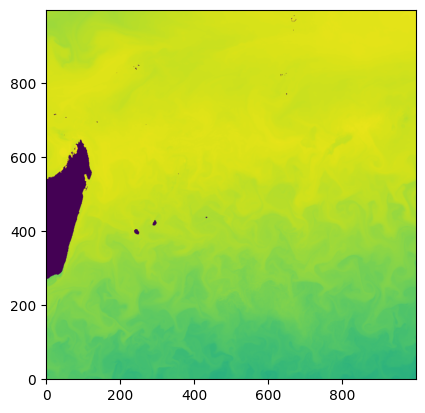

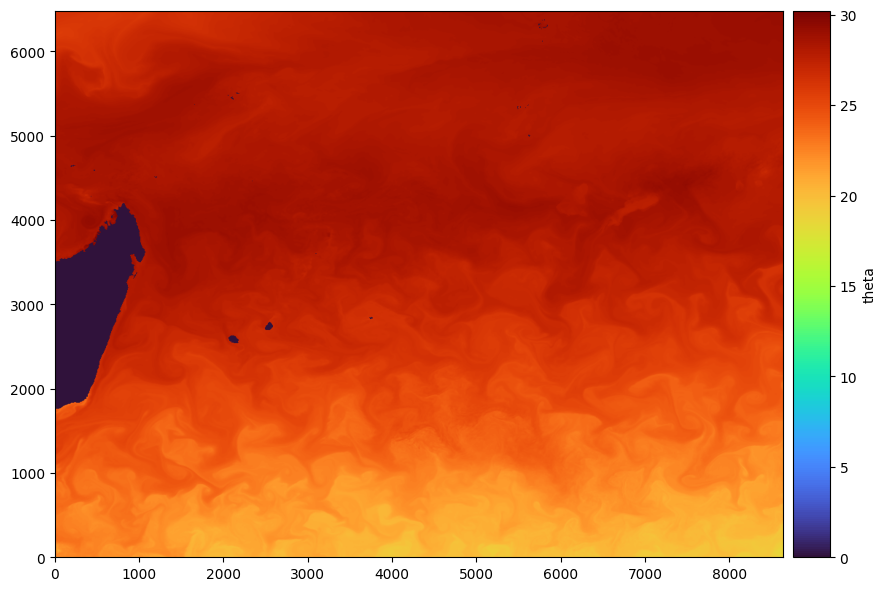

In [2]:
data = get_ocean_var('theta', time=0, quality=0, x=[2000,3000], y=[3000,4000], z=[0,1], to_print=True)

vals, counts = np.unique(data, return_counts=True)
print(type(data), data.shape)
print(np.max(counts), np.argmax(counts), vals[np.argmax(counts)])

for i in np.unique(data, return_counts=True):
  print(i)

data_lastz = get_ocean_var('theta', time=0, quality=0, x=[600, 1200], y=[500, 1600], z=[89,90], to_print=True)

vals, counts = np.unique(data_lastz, return_counts=True)
print()

plt.imshow(data[0],origin='lower')

fig,axes=plt.subplots(1,1, figsize=(10,8))
axes.set_xlim(0,8640)
axes.set_ylim(0,6480)
im=axes.imshow(data[0,:,:],extent=[0,8640,0,6480],origin='lower',cmap='turbo')
divider = make_axes_locatable(axes)
cax = divider.append_axes("right",  size="5%", pad=0.1)  # Adjust size and pad as needed

cbar = plt.colorbar(im, cax=cax)
cbar.set_label('theta')
plt.show()

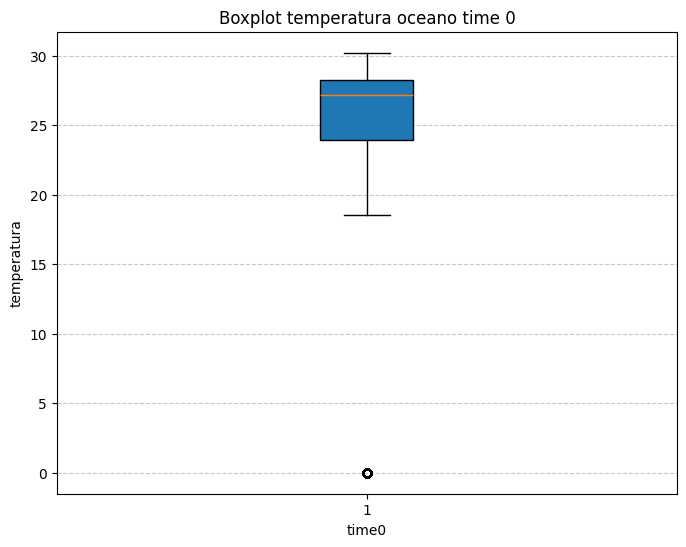

In [3]:
plt.figure(figsize=(8,6))
plt.boxplot(data.flatten(), patch_artist=True)

plt.title('Boxplot temperatura oceano time 0')
plt.xlabel('time0')
plt.ylabel('temperatura')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [ ]:
#!rm llc2160_latlon.nc

#!wget https://raw.githubusercontent.com/sci-visus/sciviscontest2026/main/notebooks_examples/llc2160_latlon.nc

--2026-06-13 08:56:55--  https://raw.githubusercontent.com/sci-visus/sciviscontest2026/main/notebooks_examples/llc2160_latlon.nc
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.111.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 49023365 (47M) [application/octet-stream]
Saving to: ‘llc2160_latlon.nc’

llc2160_latlon.nc   100%[===================>]  46.75M  3.62MB/s    in 12s     

2026-06-13 08:57:08 (3.78 MB/s) - ‘llc2160_latlon.nc’ saved [49023365/49023365]



In [ ]:
latlon_grid = xr.open_dataset('llc2160_latlon.nc')
print(latlon_grid)

latlon_grid = xr.open_dataset('llc2160_latlon.nc')

lon_2d = latlon_grid['longitude'].values # matrix 2D
lat_2d = latlon_grid['latitude'].values # matrix 2D

x = [1000, 3000]
y= [500, 2000]

lon_cut = lon_2d[500:4000, 2000:4000]
lat_cut = lat_2d[500:4000, 2000:4000]
Z_cut = np.zeros_like(lon_cut)

theta_slice = get_ocean_var('theta', 0, 0, [2000, 4000], [500, 4000], [0,1], True)

grid = pv.StructuredGrid(lon_cut, lat_cut, Z_cut)
grid['theta'] = theta_slice.flatten(order='F')

pv.set_jupyter_backend('html')
plotter = pv.Plotter(notebook=True)
plotter.add_mesh(
    grid,
    scalars= 'theta',
    cmap='YlGnBu',
    show_edges=False
)
plotter.show()


<xarray.Dataset> Size: 448MB
Dimensions:    (y: 6480, x: 8640)
Coordinates:
  * y          (y) int64 52kB 0 1 2 3 4 5 6 ... 6474 6475 6476 6477 6478 6479
  * x          (x) int64 69kB 0 1 2 3 4 5 6 ... 8634 8635 8636 8637 8638 8639
Data variables:
    latitude   (y, x) float32 224MB ...
    longitude  (y, x) float32 224MB ...
Attributes:
    title:        LLC2160 Mosaic Grid
    description:  Latitude and Longitude mosaic from LLC2160 faces 0, 1, 3, 4
    Conventions:  CF-1.8
    source:       Generated from MITgcm LLC2160 binary grid data
Dimensions: 8640*6480*90
Total Timesteps: 10366
Field: theta
Data Type: float32
